In [2]:
import stlrom as stl
from stlrom import Signal, OscillSignalGen, RandSignalGen

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

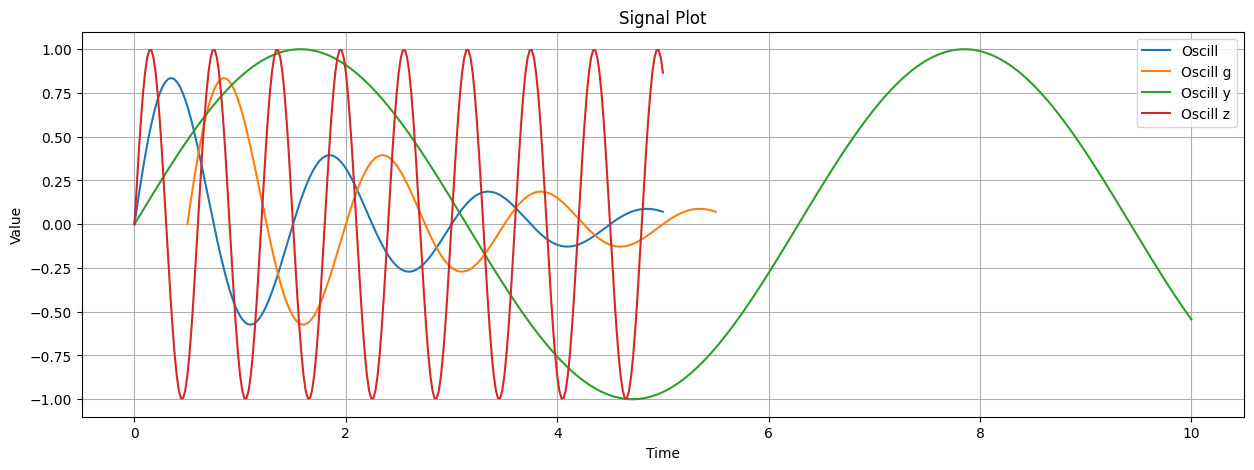

In [3]:
osc_gen  = OscillSignalGen()
sin_sig = osc_gen.get_signal(t0=0, tf=5, dt=0.02, damp=-0.5, period=1.5)
# sin_sig = RandSignalGen(interp='LINEAR').get_signal(t0=0, tf=5)
g_sig = sin_sig.copy()
g_sig.shift(0.5)


y_sig = osc_gen.get_signal(t0=0, tf=10, dt=0.02, damp=0, period=2*3.141592653)

z_sig = osc_gen.get_signal(t0=0, tf=5, dt=0.02, damp=0, period=0.6)

ax = sin_sig.plot(label='Oscill')
g_sig.plot(ax=ax, label='Oscill g')
y_sig.plot(label='Oscill y', ax=ax)

z_sig.plot(label='Oscill z', ax=ax)

In [ ]:
driver = stl.STLDriver()
driver.parse_string(
    """
    signal x, y, z, g
    param p = 0, q = 0.02, delta=0.01, dt=0.5
    max_local := ev[p,q] (x[t-delta]>0)
    min_local := alw[p,q] (x[t-delta]>0)
    diff_local := max_local[t]-min_local[t] > 0
    x_sup := x[t] > 0
    x_inv := inv(x[t]) > 0

    alw_x := alw_[0, dt] x_sup
    hist_x := hist_[0, dt] x_sup
    alw_xinv := alw_[0,dt] x_inv
    alw_xinv_shifted := alw_xinv[t+dt] > 0

    ev_x := ev_[0,dt] x_sup
    once_x := once_[0,dt] x_sup

    
    g_sup := g[t] > 0
    g_inv := inv(g[t] > 0)
    x_shifted := x[t-0.5] > 0
    ev_g := ev[0,0.1] g_sup
    ev_x_shifted := ev[0,0.5] x_shifted
    max_shifted := max_local[t-0.2] > 0
    
    opt_local := diff_local[t] < 0.5*delta

    x_until_g := x_sup until_[0,dt] g_sup
    x_since_g := x_sup since_[0,dt] g_sup

    sin := y[t]
    cos := 10*(y[t]-y[t-0.1]) > 0
    sig_sum := sin[t] + cos[t]
    sum_comp := sig_sum[t] > 0
    """)
driver.set_signals([sin_sig, y_sig, z_sig, g_sig])
print(driver)

# STLDriver object defined as
signal g, x, y, z
param delta=0.01, dt=0.5, p=0, q=0.02

# With formulas:
alw_x:= alw_[0,dt] (x[t] > 0)
alw_xinv:= alw_[0,dt] (inv(x[t]) > 0)
alw_xinv_shifted:= alw_xinv[t+0.5] > 0
cos:= 10 * (y[t] - y[t-0.1]) > 0
diff_local:= max_local[t] - min_local[t] > 0
ev_g:= ev_[0,0.1] (g[t] > 0)
ev_x:= ev_[0,dt] (x[t] > 0)
ev_x_shifted:= ev_[0,0.5] (x[t-0.5] > 0)
g_inv:= inv(g[t] > 0)
g_sup:= g[t] > 0
hist_x:= inv((alw_[0,dt] (inv(x[t] > 0)))[t+0.5])
max_local:= ev_[p,q] (x[t-0.01] > 0)
max_shifted:= max_local[t-0.2] > 0
min_local:= alw_[p,q] (x[t-0.01] > 0)
once_x:= inv((ev_[0,dt] (inv(x[t] > 0)))[t+0.5])
opt_local:= diff_local[t] < 0.5 * delta
sum_comp:= sig_sum[t] > 0
x_inv:= inv(x[t]) > 0
x_shifted:= x[t-0.5] > 0
x_sup:= x[t] > 0
x_until_g:= (x[t] > 0) until_[0,dt] (g[t] > 0)

# With functions:
sig_sum:= sin[t] + cos[t]
sin:= y[t]

# Data:
# Signal g:
# 251 samples from t0=0.5 to t_end=5.5
# Signal x:
# 251 samples from t0=0 to t_end=5
# Signal y:
# 501 samples

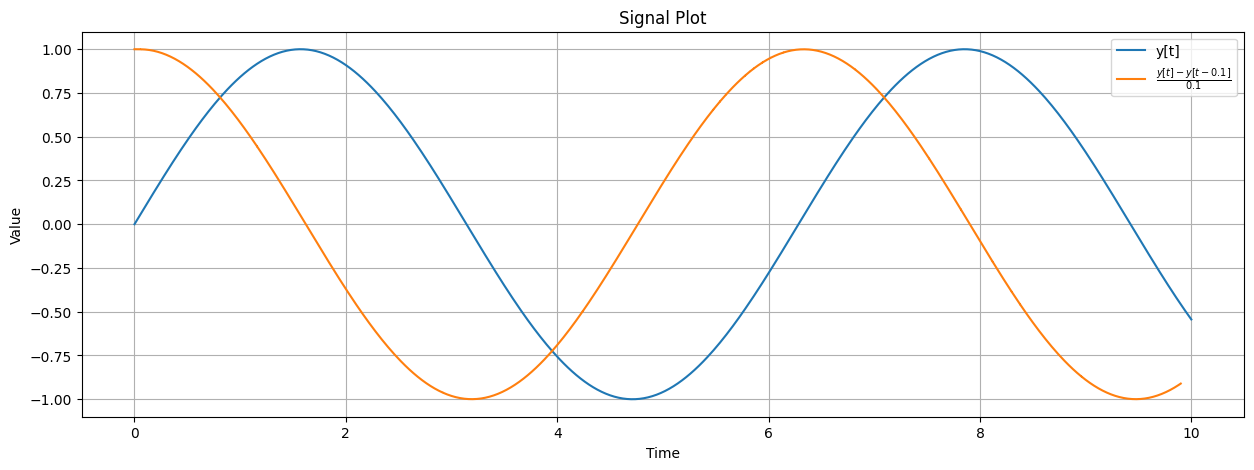

In [9]:
ax = y_sig.plot(label='y[t]')
r_cos = driver.get_rob_signal('cos', 0, 9.9)
ax = r_cos.plot(ax=ax, label='$\\frac{y[t]-y[t-0.1]}{0.1}$')

r_sum = driver.get_rob_signal('sum_comp', 0, 9.9)

# r_sum.plot(label='sum_comp', ax=ax)

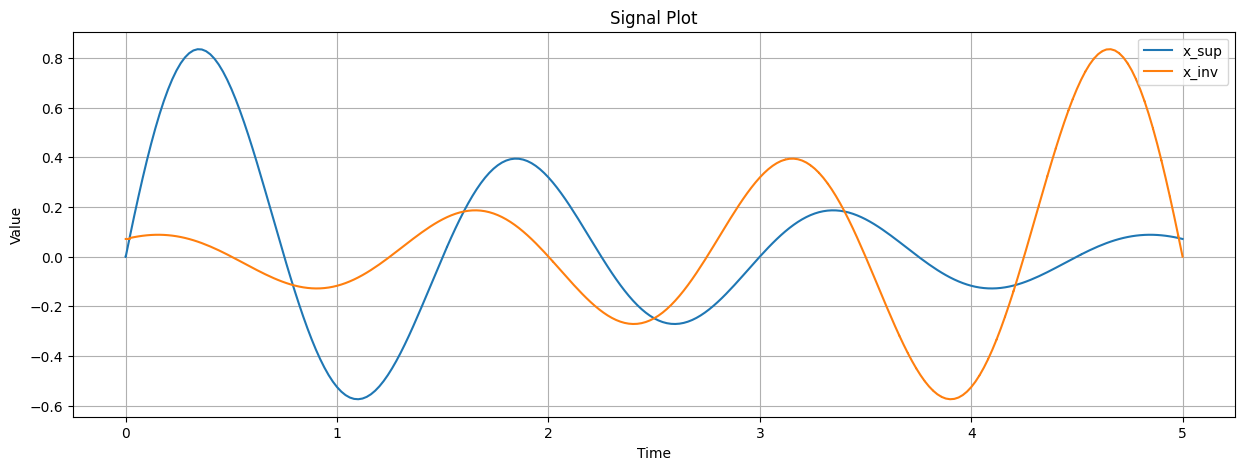

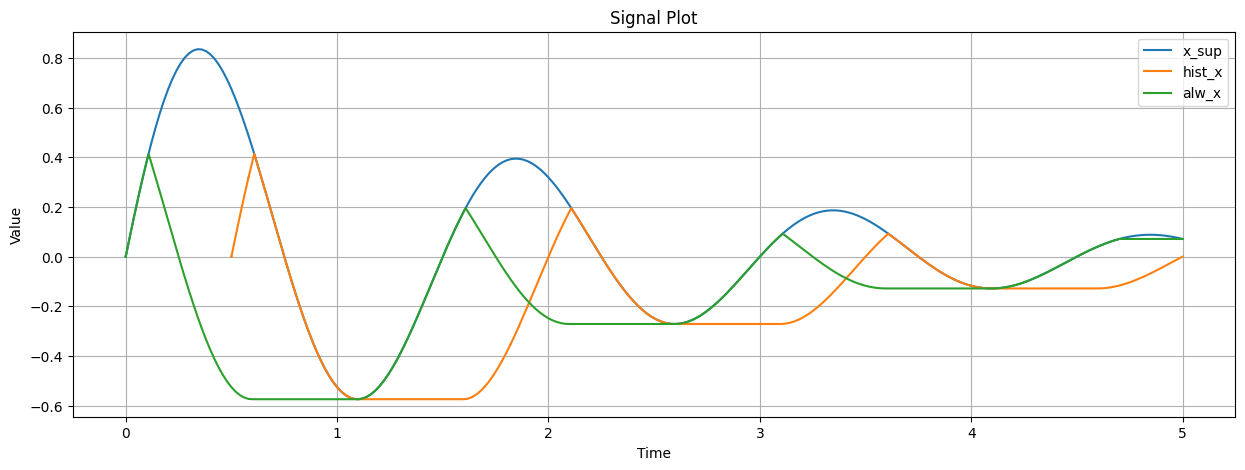

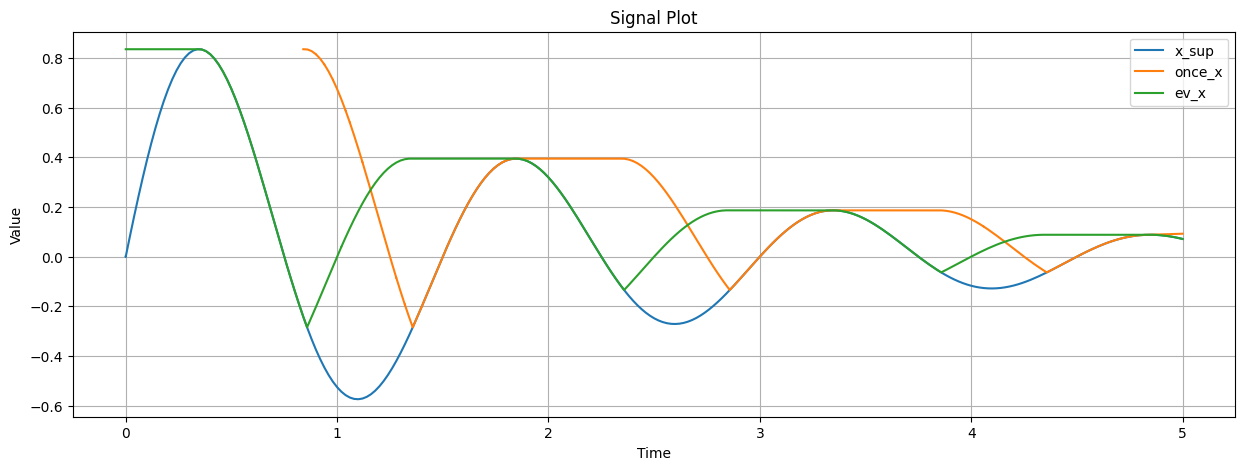

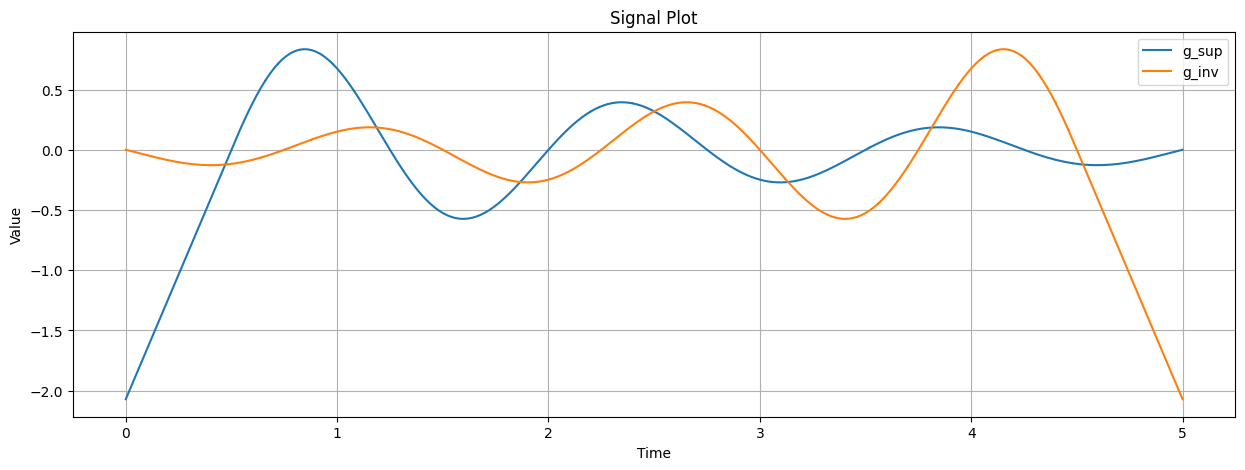

In [10]:
phis = ['x_sup', 'x_inv', 'alw_xinv_shifted', 'alw_x', 'hist_x']
phiset = [['x_sup', 'x_inv'], ['x_sup', 'hist_x', 'alw_x'], ['x_sup', 'once_x', 'ev_x'], ['g_sup', 'g_inv']]
# phis = ['x_inv', 'alw_xinv_shifted', 'hist_x']

for phis in phiset:
    ax = None
    for phi in phis:
        # end = 5 if phi == 'x_inv' else 5;
        r = driver.get_rob_signal(phi, 0, 5)
        ax = r.plot(ax=ax, label=phi, draw_samples=False)
        # print(r)

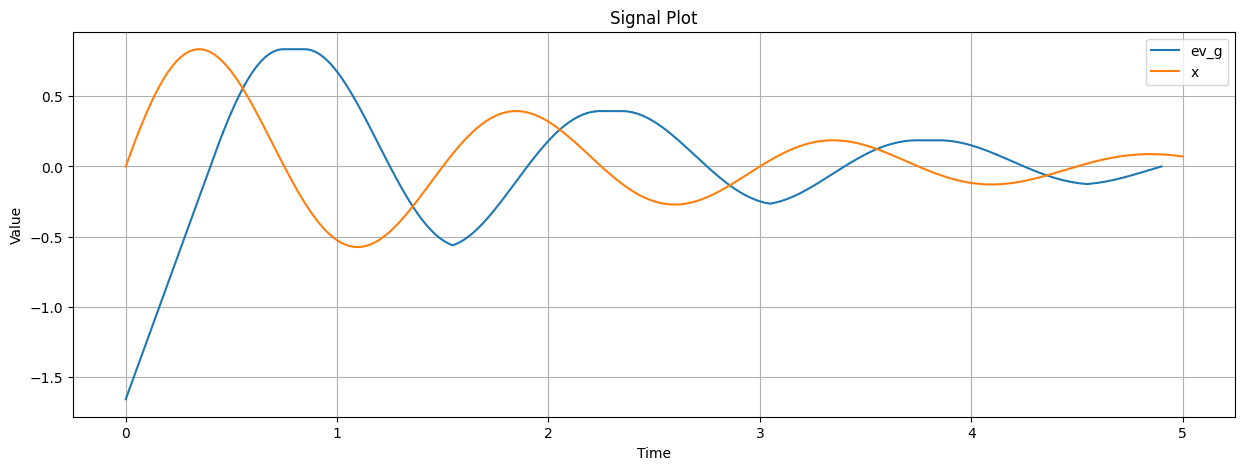

In [11]:
phi = 'ev_g'

r = driver.get_rob_signal(phi, 0, 4.9)
ax = r.plot(ax=None, label=phi)
ax = sin_sig.plot(ax=ax, label='x')
# print(r_sup)
# print(sin_sig)

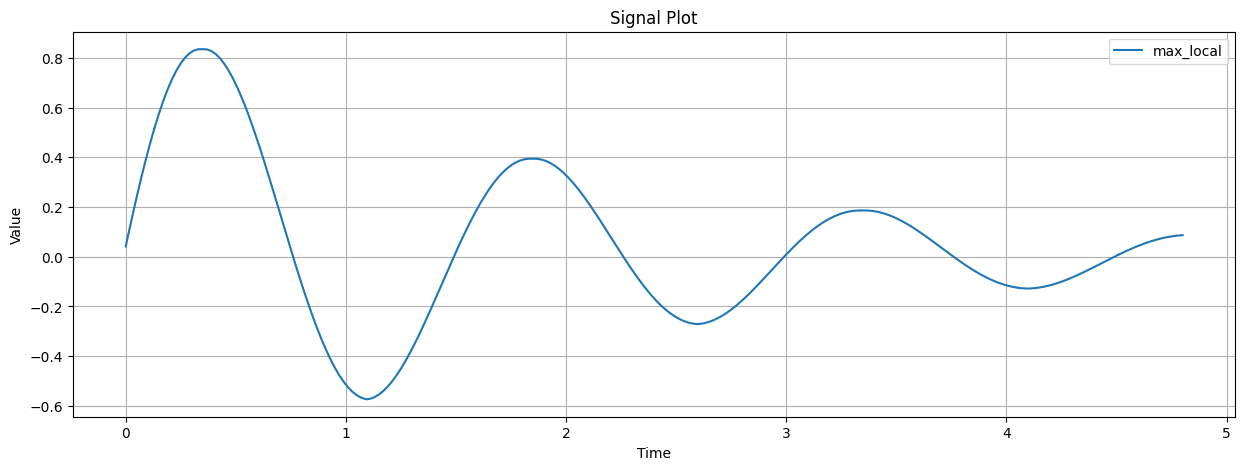

In [12]:
tmin = 0
tmax = 4.8
draw_samples=False

r_max= driver.get_rob_signal('max_local', tmin, tmax)
# print(r_max)
ax = r_max.plot(label='max_local', draw_samples=draw_samples)

# r_max_shifted = driver.get_rob_signal('max_shifted', tmin, tmax)
# ax = r_max_shifted.plot(ax=ax, label='max_local (shifted)', draw_samples=draw_samples)

0.65000000000000002220446049250313     0.32   -2.946
0.69000000000000005773159728050814     0.21   -2.961
0.71000000000000007549516567451064     0.15   -2.954
0.7299999999999999822364316059975    0.087   -2.926
                             0.75    0.029   -2.878
0.76004999954859242539129127180786   -1e-10        0
0.76004999961808261677020936986082   -1e-10   -2.878
0.7700000000000000177635683940025   -0.029   -2.811
0.79000000000000003552713678800501   -0.085   -2.725


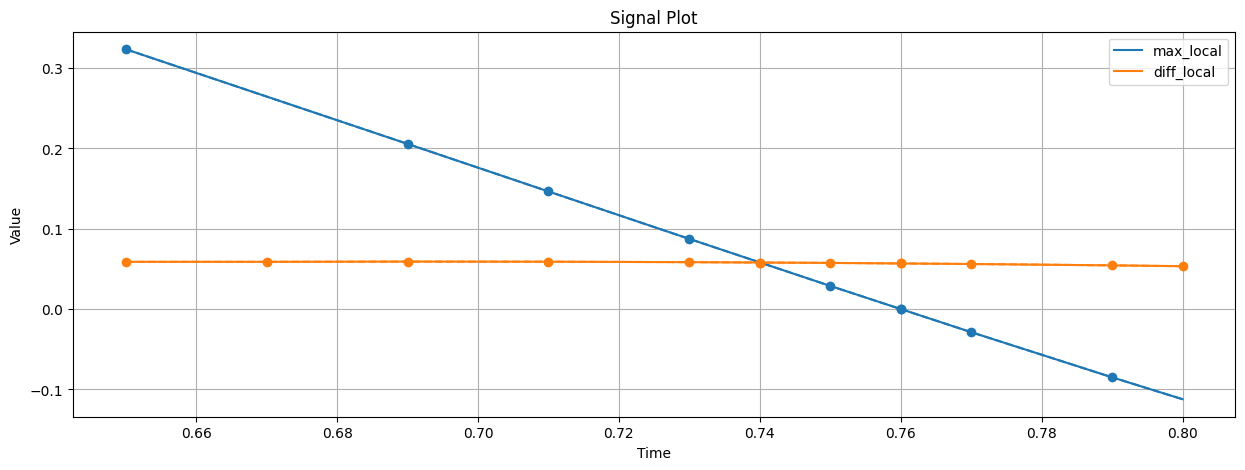

In [13]:
tmin = 0.1
tmax = 4.8
draw_samples=False

tmin = 0.65
tmax = 0.8
draw_samples = True


# r_min= driver.get_rob_signal('min_local', tmin, tmax)
# ax = r_min.plot('min_local', draw_samples=draw_samples)

r_max= driver.get_rob_signal('max_local', tmin, tmax)
ax = r_max.plot(label='max_local', draw_samples=draw_samples)

r_diff = driver.get_rob_signal('diff_local', tmin, tmax)
r_diff.plot('diff_local', ax=ax, draw_samples=draw_samples)

# r_sup = driver.get_rob_signal('x_sup', tmin, tmax)
# r_sup.plot('x>0', ax=ax, draw_samples=draw_samples)


for i in range(r_max.get_samples_list().__len__()):
    s = r_max.get_samples_list()[i]
    print(f"{s.time:>33.32g}  {s.value:>7.2g}  {s.derivative:>7.4g}")

# print(r_min)
# print(r_max)
# print(r_diff)
# print(r_sup)

# r_opt = driver.get_rob_signal('opt_local', 0, 4.9)
# ax_opt = sin_sig.plot('x')
# r_opt.plot('opt_local', ax=ax_opt, plot_sat=True, plot_rob=True)


                                0    0.041    4.142
0.0099999999999999984734433411404098    0.083    4.031
0.030000000000000002359223927328458     0.16    3.894
0.050000000000000002775557561562891     0.24    3.732
0.069999999999999992783550339936482     0.32    3.546
0.08999999999999999666933092612453     0.39     3.34
0.11000000000000001443289932012704     0.45    3.114
0.13000000000000003219646771412954     0.52    2.871
0.15000000000000002220446049250313     0.57    2.612
0.17000000000000001221245327087672     0.63     2.34
0.19000000000000002997602166487923     0.67    2.057
0.21000000000000001998401444325282     0.71    1.765
0.23000000000000000999200722162641     0.75    1.466
                             0.25     0.78    1.163
0.2700000000000000177635683940025      0.8   0.8576
0.29000000000000003552713678800501     0.82   0.5524
0.30999999999999999777955395074969     0.83   0.2493
0.33000000000000001554312234475219     0.83        0
0.3500000000000000333066907387547     0.83  

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

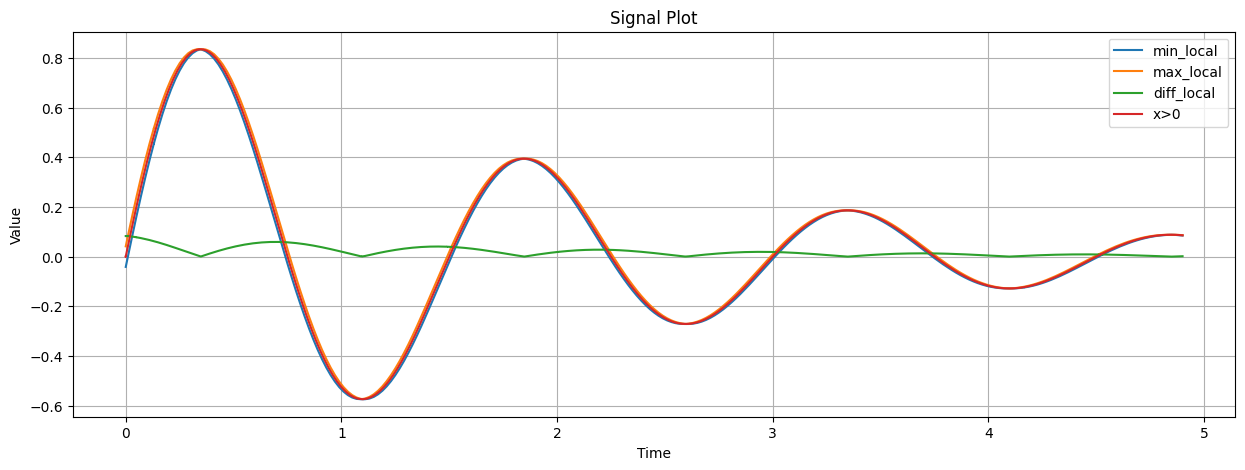

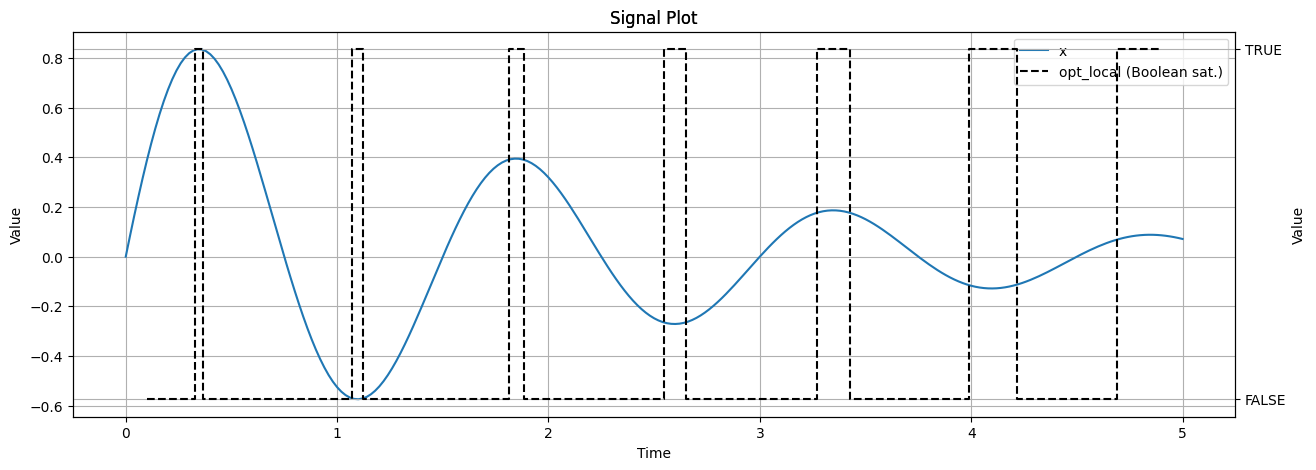

In [14]:
tmin = 0
tmax = 4.9
draw_samples=False

# tmin = 0.3
# tmax = 0.4
# draw_samples = True


r_min= driver.get_rob_signal('min_local', tmin, tmax)
ax = r_min.plot('min_local', draw_samples=draw_samples)
r_max= driver.get_rob_signal('max_local', tmin, tmax)
r_max.plot(ax=ax, label='max_local', draw_samples=draw_samples)

r_diff = driver.get_rob_signal('diff_local', tmin, tmax)
r_diff.plot('diff_local', ax=ax, draw_samples=draw_samples)

r_sup = driver.get_rob_signal('x_sup', tmin, tmax)
r_sup.plot('x>0', ax=ax, draw_samples=draw_samples)


for i in range(r_max.get_samples_list().__len__()):
    s = r_max.get_samples_list()[i]
    print(f"{s.time:>33.32g}  {s.value:>7.2g}  {s.derivative:>7.4g}")

print(r_min)
print(r_max)
print(r_diff)
print(r_sup)

r_opt = driver.get_rob_signal('opt_local', 0.1, 4.9)
ax_opt = sin_sig.plot('x')
r_opt.plot('opt_local', ax=ax_opt, plot_sat=True, plot_rob=False)
